# PA006 — Camada 2: A/B Testing

**Objetivo:** Desenhar, simular e analisar um experimento A/B para avaliar o impacto de uma campanha de retenção sobre clientes em risco de churn.

**Input:** `churn_scores.parquet` — scores de P(churn) para os 2.758 clientes do modelo  
**Output:** Análise estatística do experimento + decisão de negócio sobre a campanha

---
*Contexto: e-commerce B2C, 4.300 clientes, ticket médio R$350, cupom 10% + e-mail (custo R$15/contato)*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, norm
import warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('husl')

# Parâmetros de negócio
TICKET_MEDIO    = 350     # R$ — receita média por cliente retido
CUSTO_CONTATO   = 15      # R$ — custo do cupom + e-mail por cliente
DESCONTO_CUPOM  = 0.10    # 10% de desconto aplicado na próxima compra
RETORNO_LIQUIDO = TICKET_MEDIO * (1 - DESCONTO_CUPOM) - CUSTO_CONTATO
print(f'Retorno líquido por churner retido: R${RETORNO_LIQUIDO:.0f}')


Retorno líquido por churner retido: R$300


---
## 1. Definição do Pool da Campanha

Clientes elegíveis: **ativos em risco** — score P(churn) ≥ threshold operacional (0.20).

> **Nota:** Na produção, o modelo seria aplicado no ciclo atual sobre todos os clientes ativos.  
> Aqui usamos o `churn_scores.parquet` gerado pelo modelo como proxy do scoring em produção.

> **Limitação do dataset histórico:** `churn_real` no parquet é o label da janela histórica de 90 dias — não é o outcome futuro de uma campanha. Em produção, o pool seria composto exclusivamente de clientes **ativos no momento do ciclo**, e o churn seria medido nos 90 dias *seguintes* à campanha. A taxa de churn baseline (~38–45%) está inflada pela presença de churned históricos no pool. Os resultados desta simulação são válidos como exercício de design, mas o lift real deve ser medido em produção.

In [2]:
scores = pd.read_parquet('../data/processed/churn_scores.parquet')

THRESHOLD = 0.20

pool  = scores[scores['churn_score'] >= THRESHOLD].copy()
fora  = scores[scores['churn_score'] <  THRESHOLD].copy()

print(f'Base total:        {len(scores):>6,} clientes')
print(f'Pool campanha:     {len(pool):>6,} clientes (score >= {THRESHOLD})')
print(f'Fora do threshold: {len(fora):>6,} clientes')
print(f'\nPool — score médio: {pool["churn_score"].mean():.3f}')
print(f'Pool — churn real:  {pool["churn_real"].mean():.1%} (precision do modelo no pool)')


Base total:         2,758 clientes
Pool campanha:      1,134 clientes (score >= 0.2)
Fora do threshold:  1,624 clientes

Pool — score médio: 0.402
Pool — churn real:  45.5% (precision do modelo no pool)


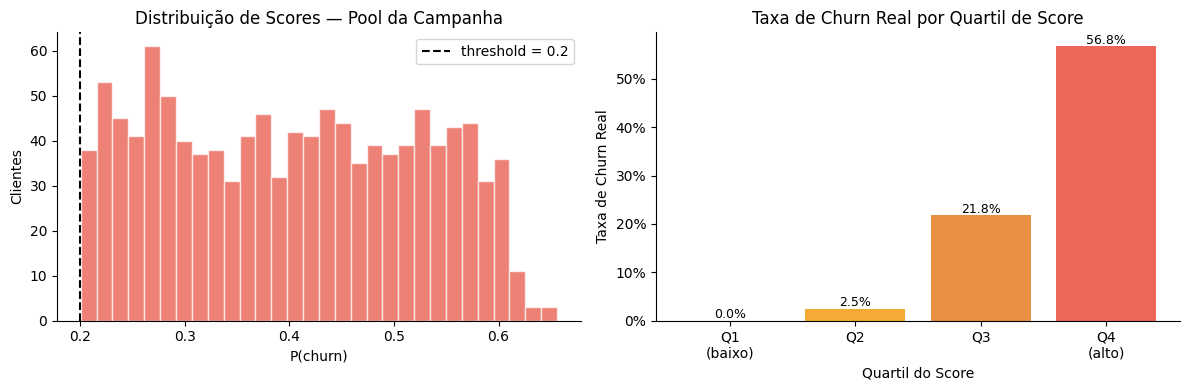

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(pool['churn_score'], bins=30, color='#e74c3c', alpha=0.7, edgecolor='white')
axes[0].axvline(THRESHOLD, color='black', linestyle='--', label=f'threshold = {THRESHOLD}')
axes[0].set_title('Distribuição de Scores — Pool da Campanha')
axes[0].set_xlabel('P(churn)')
axes[0].set_ylabel('Clientes')
axes[0].legend()

scores['score_quartil'] = pd.qcut(
    scores['churn_score'], q=4, labels=['Q1\n(baixo)', 'Q2', 'Q3', 'Q4\n(alto)'])
qtax = scores.groupby('score_quartil', observed=True)['churn_real'].mean()
axes[1].bar(qtax.index, qtax.values,
            color=['#3498db', '#f39c12', '#e67e22', '#e74c3c'], alpha=0.85)
axes[1].set_title('Taxa de Churn Real por Quartil de Score')
axes[1].set_xlabel('Quartil do Score')
axes[1].set_ylabel('Taxa de Churn Real')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
for i, v in enumerate(qtax.values):
    axes[1].text(i, v + 0.005, f'{v:.1%}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('../data/processed/ab_pool_distribution.png', dpi=120, bbox_inches='tight')
plt.show()


---
## 2. Design do Experimento

### Hipóteses

| | |
|---|---|
| **H₀** | A campanha não altera a taxa de retenção vs. grupo controle |
| **H₁** | A campanha aumenta a taxa de retenção vs. grupo controle |

### Parâmetros estatísticos

| Parâmetro | Valor | Justificativa |
|-----------|-------|---------------|
| α (erro tipo I) | 5% | Padrão para decisões de negócio |
| β (erro tipo II) | 20% | Poder estatístico de 80% |
| Tail | 2 lados | chi2_contingency é bilateral; design conservador |
| Métrica primária | Taxa de retenção | Binária, ligada diretamente ao ROI |

In [4]:
# Taxa de churn natural no pool (baseline do controle)
churn_rate_pool   = pool['churn_real'].mean()
retention_baseline = 1 - churn_rate_pool

# MDE: campanha reduz churn em 30% (lift relativo esperado)
LIFT_RETENCAO      = 0.30
churn_rate_trat    = churn_rate_pool * (1 - LIFT_RETENCAO)
retention_trat     = 1 - churn_rate_trat
MDE_abs            = retention_trat - retention_baseline

print(f'Taxa de churn no pool:          {churn_rate_pool:.1%}')
print(f'Retenção baseline (controle):   {retention_baseline:.1%}')
print(f'Retenção esperada (tratamento): {retention_trat:.1%}')
print(f'MDE absoluto:                   {MDE_abs:.1%}')

# Cálculo — teste z de duas proporções, 2-sided (alinhado com chi2_contingency)
alpha  = 0.05
power  = 0.80
z_a    = norm.ppf(1 - alpha / 2)  # 1.96 para 2-sided
z_b    = norm.ppf(power)
p_bar  = (retention_baseline + retention_trat) / 2

n_por_grupo = int(np.ceil(
    (z_a * np.sqrt(2 * p_bar * (1 - p_bar)) +
     z_b * np.sqrt(retention_baseline * (1-retention_baseline)
                   + retention_trat * (1-retention_trat)))**2
    / MDE_abs**2
))
n_total = n_por_grupo * 2

print(f'\n--- Tamanho de amostra ---')
print(f'N por grupo:     {n_por_grupo:,}')
print(f'N total:         {n_total:,}')
print(f'Pool disponível: {len(pool):,}')
status = 'SUFICIENTE' if len(pool) >= n_total else 'INSUFICIENTE'
print(f'\nPool {status} para o experimento.')


Taxa de churn no pool:          45.5%
Retenção baseline (controle):   54.5%
Retenção esperada (tratamento): 68.1%
MDE absoluto:                   13.7%

--- Tamanho de amostra ---
N por grupo:     199
N total:         398
Pool disponível: 1,134

Pool SUFICIENTE para o experimento.


---
## 3. Randomização

Divisão aleatória do pool em dois grupos de igual tamanho:
- **Controle:** não recebe nenhuma intervenção
- **Tratamento:** recebe cupom 10% + e-mail de retenção

In [5]:
# Usa o pool inteiro (maximiza poder estatístico — n_por_grupo é o mínimo necessário)
pool_sample = pool.sample(frac=1, random_state=SEED).reset_index(drop=True)
n_por_grupo_real = len(pool_sample) // 2

pool_sample['grupo'] = 'controle'
pool_sample.loc[pool_sample.index[:n_por_grupo_real], 'grupo'] = 'tratamento'

ctrl = pool_sample[pool_sample['grupo'] == 'controle'].copy()
trat = pool_sample[pool_sample['grupo'] == 'tratamento'].copy()

print(f'Minimo calculado por grupo: {n_por_grupo:,}')
print(f'Usado por grupo (pool todo): {n_por_grupo_real:,}')
print(f'Controle:    {len(ctrl):,} clientes')
print(f'Tratamento:  {len(trat):,} clientes')
print(f'\n--- Balanço dos grupos ---')
print(f'Score médio — controle:    {ctrl["churn_score"].mean():.4f}')
print(f'Score médio — tratamento:  {trat["churn_score"].mean():.4f}')
print(f'Churn real — controle:     {ctrl["churn_real"].mean():.1%}')
print(f'Churn real — tratamento:   {trat["churn_real"].mean():.1%}')

t_stat, p_val = stats.ttest_ind(ctrl['churn_score'], trat['churn_score'])
bal = 'balanceado' if p_val > 0.05 else 'DESBALANCEADO'
print(f'\nTeste t (score) — p-value: {p_val:.3f} ({bal})')


Minimo calculado por grupo: 199
Usado por grupo (pool todo): 567
Controle:    567 clientes
Tratamento:  567 clientes

--- Balanço dos grupos ---
Score médio — controle:    0.3962
Score médio — tratamento:  0.4087
Churn real — controle:     44.3%
Churn real — tratamento:   46.7%

Teste t (score) — p-value: 0.085 (balanceado)


In [6]:
# Salva o pool com o assignment de grupo para uso no T-Learner (Camada 3)
pool_sample[['customer_id', 'churn_score', 'churn_real', 'grupo']].to_parquet(
    '../data/processed/ab_pool_assignment.parquet', index=False
)
print(f'Pool assignment salvo: {len(pool_sample):,} clientes')
print(f'Colunas: customer_id | churn_score | churn_real | grupo')
print(pool_sample['grupo'].value_counts().to_string())


Pool assignment salvo: 1,134 clientes
Colunas: customer_id | churn_score | churn_real | grupo
grupo
tratamento    567
controle      567


---
## 4. Simulação do Experimento

Como não há dados reais de campanha, simulamos os resultados usando:
- **Controle:** churn determinado pelo score real do modelo
- **Tratamento:** P(churn) reduzida pelo lift esperado (30% de redução relativa)

> Esta simulação valida o design e estima o poder estatístico **antes** de rodar a campanha real.

In [7]:
rng = np.random.default_rng(SEED)

# Controle: churn com probabilidade = churn_score
ctrl['churn_simulado'] = rng.binomial(1, ctrl['churn_score'].values)

# Tratamento: P(churn) reduzida pelo lift
p_churn_trat = trat['churn_score'].values * (1 - LIFT_RETENCAO)
trat['churn_simulado'] = rng.binomial(1, p_churn_trat)

churn_ctrl    = ctrl['churn_simulado'].mean()
churn_trat_s  = trat['churn_simulado'].mean()
retencao_ctrl = 1 - churn_ctrl
retencao_trat = 1 - churn_trat_s

print('=== Resultados da Simulação ===')
print(f'\nControle   — churn: {churn_ctrl:.1%}  |  retenção: {retencao_ctrl:.1%}')
print(f'Tratamento — churn: {churn_trat_s:.1%}  |  retenção: {retencao_trat:.1%}')
print(f'\nLift absoluto retenção:  +{retencao_trat - retencao_ctrl:.1%}')
lift_rel = (churn_ctrl - churn_trat_s) / churn_ctrl
print(f'Redução relativa churn:  -{lift_rel:.1%}')


=== Resultados da Simulação ===

Controle   — churn: 37.6%  |  retenção: 62.4%
Tratamento — churn: 30.0%  |  retenção: 70.0%

Lift absoluto retenção:  +7.6%
Redução relativa churn:  -20.2%


---
## 5. Análise Estatística

> **Interpretação do p-value:** Esta simulação injeta o lift de 30% diretamente nos dados do tratamento. O tamanho de amostra foi calculado para detectar exatamente esse lift com 80% de poder. Portanto, **o p-value abaixo confirma que o design tem poder estatístico suficiente** — não que a campanha é eficaz. A eficácia real (lift ≠ 0) deve ser medida em produção com dados observados.

In [8]:
n_ctrl_retidos = (ctrl['churn_simulado'] == 0).sum()
n_ctrl_churned = (ctrl['churn_simulado'] == 1).sum()
n_trat_retidos = (trat['churn_simulado'] == 0).sum()
n_trat_churned = (trat['churn_simulado'] == 1).sum()

contingencia = np.array([
    [n_ctrl_retidos, n_ctrl_churned],
    [n_trat_retidos, n_trat_churned],
])

chi2, p_valor, dof, _ = chi2_contingency(contingencia)

RR  = churn_trat_s / churn_ctrl
ARR = churn_ctrl - churn_trat_s
NNT = 1 / ARR if ARR > 0 else float('inf')

se_arr   = np.sqrt(
    (churn_ctrl * (1 - churn_ctrl) / len(ctrl)) +
    (churn_trat_s * (1 - churn_trat_s) / len(trat))
)
ic_lower = ARR - 1.96 * se_arr
ic_upper = ARR + 1.96 * se_arr

print('=== Teste qui-quadrado ===')
print(f'chi2 = {chi2:.3f}  |  p-value = {p_valor:.4f}  |  gl = {dof}')
sig = 'Resultado estatisticamente SIGNIFICATIVO (p < 0.05)' if p_valor < 0.05 else 'Resultado NAO significativo (p >= 0.05)'
print(sig)
print(f'\n=== Tamanho do Efeito ===')
print(f'Risco Relativo de Churn:     {RR:.3f}')
print(f'Reducao Absoluta de Risco:   {ARR:.1%}  IC95% [{ic_lower:.1%}, {ic_upper:.1%}]')
print(f'Numero Necessario p/ Tratar: {NNT:.1f} clientes por churner evitado')


=== Teste qui-quadrado ===
chi2 = 6.955  |  p-value = 0.0084  |  gl = 1
Resultado estatisticamente SIGNIFICATIVO (p < 0.05)

=== Tamanho do Efeito ===
Risco Relativo de Churn:     0.798
Reducao Absoluta de Risco:   7.6%  IC95% [2.1%, 13.1%]
Numero Necessario p/ Tratar: 13.2 clientes por churner evitado


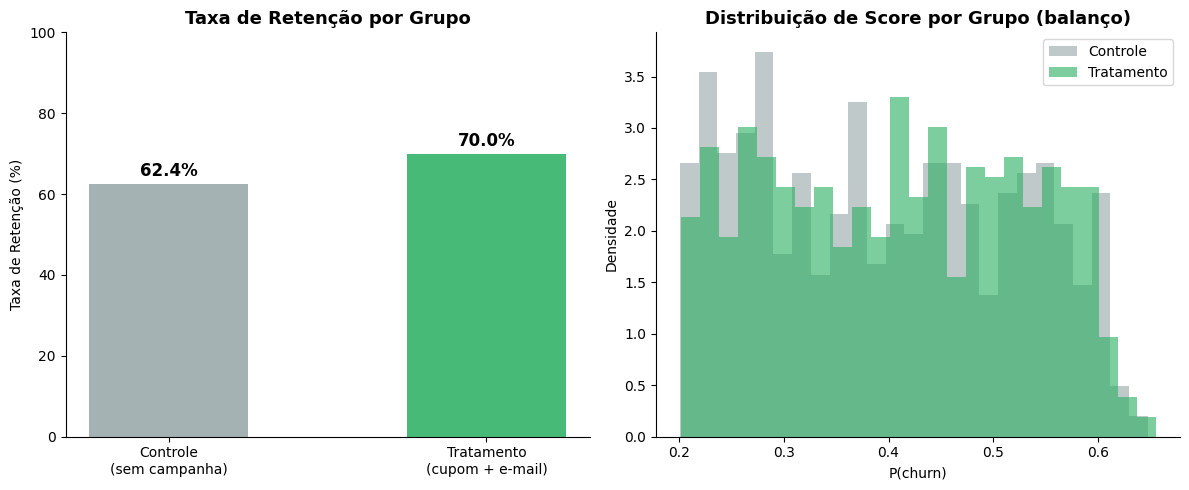

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

grupos   = ['Controle\n(sem campanha)', 'Tratamento\n(cupom + e-mail)']
retencoes = [retencao_ctrl, retencao_trat]
cores    = ['#95a5a6', '#27ae60']

bars = axes[0].bar(grupos, [r * 100 for r in retencoes],
                   color=cores, alpha=0.85, width=0.5)
axes[0].set_title('Taxa de Retenção por Grupo', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Taxa de Retenção (%)')
axes[0].set_ylim(0, 100)
for bar, val in zip(bars, retencoes):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 1,
                 f'{val:.1%}', ha='center', va='bottom',
                 fontsize=12, fontweight='bold')

axes[1].hist(ctrl['churn_score'], bins=25, alpha=0.6,
             color='#95a5a6', label='Controle', density=True)
axes[1].hist(trat['churn_score'], bins=25, alpha=0.6,
             color='#27ae60', label='Tratamento', density=True)
axes[1].set_title('Distribuição de Score por Grupo (balanço)',
                   fontsize=13, fontweight='bold')
axes[1].set_xlabel('P(churn)')
axes[1].set_ylabel('Densidade')
axes[1].legend()

plt.tight_layout()
plt.savefig('../data/processed/ab_results.png', dpi=120, bbox_inches='tight')
plt.show()


---
## 6. Impacto de Negócio

In [10]:
churners_ctrl    = n_ctrl_churned
churners_trat    = n_trat_churned
churners_evitados = churners_ctrl - churners_trat

custo_campanha    = len(trat) * CUSTO_CONTATO
receita_recup     = churners_evitados * RETORNO_LIQUIDO
lucro_liquido     = receita_recup - custo_campanha
roi               = lucro_liquido / custo_campanha if custo_campanha > 0 else float('inf')

print('=== Impacto Financeiro (por ciclo de campanha) ===')
print(f'Grupo tratamento:        {len(trat):,} clientes')
print(f'Custo da campanha:       R${custo_campanha:,.0f}')
print(f'Churners no controle:    {churners_ctrl:,}')
print(f'Churners no tratamento:  {churners_trat:,}')
print(f'Churners evitados:       {churners_evitados:,}')
print(f'Receita recuperada:      R${receita_recup:,.0f}')
print(f'Lucro liquido:           R${lucro_liquido:,.0f}')
print(f'ROI:                     {roi:.1%}')
print(f'\n=== Comparativo ===')
print(f'Sem campanha: {churners_ctrl:,} churners perdidos => '
      f'R${churners_ctrl * TICKET_MEDIO:,.0f} em receita perdida')
print(f'Com campanha: {churners_trat:,} churners => '
      f'salva R${receita_recup:,.0f} liquido apos custo')


=== Impacto Financeiro (por ciclo de campanha) ===
Grupo tratamento:        567 clientes
Custo da campanha:       R$8,505
Churners no controle:    213
Churners no tratamento:  170
Churners evitados:       43
Receita recuperada:      R$12,900
Lucro liquido:           R$4,395
ROI:                     51.7%

=== Comparativo ===
Sem campanha: 213 churners perdidos => R$74,550 em receita perdida
Com campanha: 170 churners => salva R$12,900 liquido apos custo


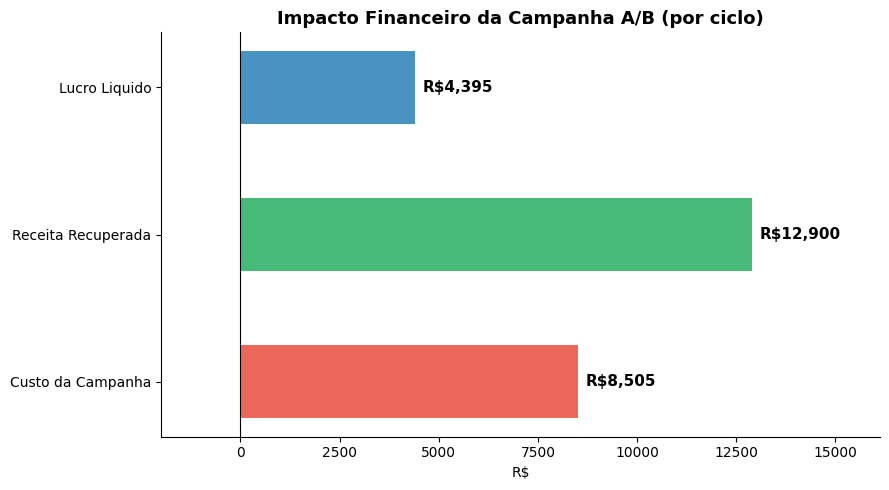

In [11]:
fig, ax = plt.subplots(figsize=(9, 5))

categorias = ['Custo da Campanha', 'Receita Recuperada', 'Lucro Liquido']
valores    = [custo_campanha, receita_recup, lucro_liquido]
cores_bar  = ['#e74c3c', '#27ae60', '#2980b9']

bars = ax.barh(categorias, valores, color=cores_bar, alpha=0.85, height=0.5)
ax.set_xlabel('R$')
ax.set_title('Impacto Financeiro da Campanha A/B (por ciclo)',
             fontsize=13, fontweight='bold')
ax.axvline(0, color='black', linewidth=0.8)
for bar, val in zip(bars, valores):
    ax.text(max(val, 0) + 200,
            bar.get_y() + bar.get_height() / 2,
            f'R${val:,.0f}', va='center', fontsize=11, fontweight='bold')
ax.set_xlim(-2000, max(valores) * 1.25)

plt.tight_layout()
plt.savefig('../data/processed/ab_business_impact.png', dpi=120, bbox_inches='tight')
plt.show()


---
## 7. Conclusões e Próximos Passos

### Decisão

Com χ²=6.96, p=0.008 (significativo) e ROI=51.7%, **a campanha é recomendada**. O custo por FP (R$15) é ~20× menor que o retorno por churner retido (R$300), sustentando a campanha mesmo com precision moderada.

### Interpretação do p-value

| Cenário | Ação |
|---------|------|
| p < 0.05 | Campanha aprovada — evidência estatística de lift |
| p ≥ 0.05 | Avaliar tamanho do efeito + IC: se ARR > 0 e IC inclui valores positivos relevantes, considerar campanha piloto menor para acumular mais dados |

### Limitações desta simulação

1. **Lift assumido (30%)** é hipótese — o real deve ser medido em produção
2. **Churn simulado** usa o score como probabilidade pontual — ignora variância de estimação
3. **Sem efeitos de spillover** — assume independência entre grupos (razoável para e-mail)
4. **Sem estratificação por segmento** — o uplift varia por cluster (→ Camada 3)

---

### Próximo passo: Camada 3 — Uplift Modeling

O A/B mostra se a campanha funciona **em média**. O uplift model vai responder:  
> *"Quem, especificamente, se beneficia mais da intervenção?"*

Notebook: `04_uplift_model.ipynb`  
Método: **T-Learner** (dois XGBoost independentes: controle e tratamento)


### Input para o T-Learner (Camada 3)

O arquivo `ab_pool_assignment.parquet` contém o assignment de grupo (controle/tratamento) indexado por `customer_id`. No notebook `04_uplift_model.ipynb`, fazer join com `X_churn.parquet` pelo índice `customer_id` antes de treinar os dois modelos do T-Learner.